# Aardaker Nergena — `aardaker_nergena_29273`

|                        |                                                  |
| ---------------------- | ------------------------------------------------ |
| **Crop**               | Aardaker (_Lathyrus tuberosus_ / tuberous pea)   |
| **Location**           | Nergena greenhouse, Wageningen, Netherlands      |
| **Year**               | 2024–2025                                        |
| **Measurements**       | 3,221                                            |
| **Genotypes**          | 392 genotypes across 3 heterotic pools (A, B, I) |
| **Owner**              | Padraic Flood                                    |
| **Protocol**           | Photosynthesis RIDES 2.0                         |
| **PhotosynQ projects** | 29273                                            |

**Experiment:** Phenotyping of _Lathyrus tuberosus_ (aardaker) genotypes under greenhouse conditions at Nergena. Genotypes span three heterotic pools (A: 643 measurements, B: 281, I: 32; 2,265 unassigned). Genotype entered directly into PhotosynQ user answers during measurement.

**Protocol features (RIDES 2.0):** The RIDES (Rapid Identification of Differential Efficiency of photosynthesis from Spectra) protocol captures a comprehensive set of photosynthesis parameters including ECS (electrochromic shift) for thylakoid proton motive force, PSI redox state via P700 absorbance changes, and PSII fluorescence. It measures under ambient light conditions, preserving the in-vivo state of the photosynthetic apparatus.


**Computed columns (30):**

| Category       | Columns                                                                                                            |
| -------------- | ------------------------------------------------------------------------------------------------------------------ |
| Photosystem II | `Phi2`, `PhiNPQ`, `PhiNO`, `NPQt`, `LEF`, `qL`, `FmPrime`, `FoPrime`, `Fs`, `FvP_over_FmP`                         |
| Chlorophyll    | `SPAD`                                                                                                             |
| Light          | `Light_Intensity_PAR`                                                                                              |
| Environment    | `Leaf_Temperature`, `Ambient_Temperature`, `Leaf_Temperature_Differential`, `Ambient_Humidity`, `Ambient_Pressure` |
| ECS            | `ECSt_mAU`, `ECS_tau`, `gHplus`, `vHplus`                                                                          |
| Photosystem I  | `PS1_Active_Centers`, `PS1_Open_Centers`, `PS1_Over_Reduced_Centers`, `PS1_Oxidized_Centers`                       |
| P700           | `P700_DIRK_ampl`, `kP700`, `tP700`, `v_initial_P700`                                                               |
| Morphology     | `leaf_angle`, `leaf_thickness`                                                                                     |

**Additional column:** `sample_raw` (VARIANT).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data import load_aardaker

df = load_aardaker(Path("data"))

In [2]:
df.head()

,measurement_id,project_id,user_id,device_id,status,timestamp,latitude,longitude,genotype,growth_status,...,PS1_Active_Centers,PS1_Open_Centers,PS1_Over_Reduced_Centers,PS1_Oxidized_Centers,P700_DIRK_ampl,kP700,tP700,v_initial_P700,leaf_angle,leaf_thickness
0,5720881,29273,142634,11:16:70:81,submitted,2025-09-05 09:57:33.569000+00:00,51.995728,5.657681,CA379,Active,...,3.716,1.743,1.461,-2.204,0.00008,813.4786,0.0012,0.065078,19.837,0.08
1,5720879,29273,142634,11:16:70:81,submitted,2025-09-05 09:56:56.628000+00:00,51.996018,5.657587,CA361,Active,...,-1.272,0.391,0.323,0.286,0.00015,767.5048,0.0013,0.115126,6.774,0.10
2,5720876,29273,142634,11:16:70:81,submitted,2025-09-05 09:56:30.027000+00:00,51.995743,5.657686,CA361,Active,...,-1.378,0.191,1.666,-0.857,0.00003,1764.4791,0.0006,0.052934,38.810,0.08
3,5720873,29273,142634,11:16:70:81,submitted,2025-09-05 09:55:37.236000+00:00,51.995741,5.657693,CA353,Active,...,-1.734,0.034,1.297,-0.331,-0.00002,2966.6277,0.0003,-0.059333,21.840,0.08
4,5720871,29273,142634,11:16:70:81,submitted,2025-09-05 09:55:11.780000+00:00,51.995740,5.657694,CA353,Active,...,-1.167,-0.653,1.849,-0.195,0.00012,80.6647,0.0124,0.009680,34.124,0.09


## Exploratory Data Analysis

[Text(0.5, 1.0, 'Measurement counts by heterotic pool'),
 Text(0.5, 0, 'Heterotic pool'),
 Text(0, 0.5, 'Count')]

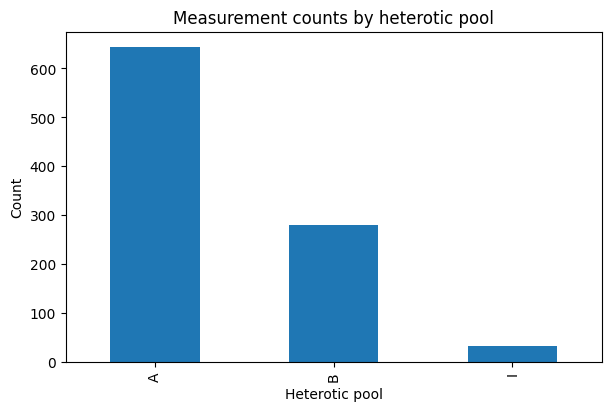

In [3]:
fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
df["heterotic_pool"].value_counts().plot(kind="bar", ax=ax)
ax.set(
    title="Measurement counts by heterotic pool",
    xlabel="Heterotic pool",
    ylabel="Count",
)

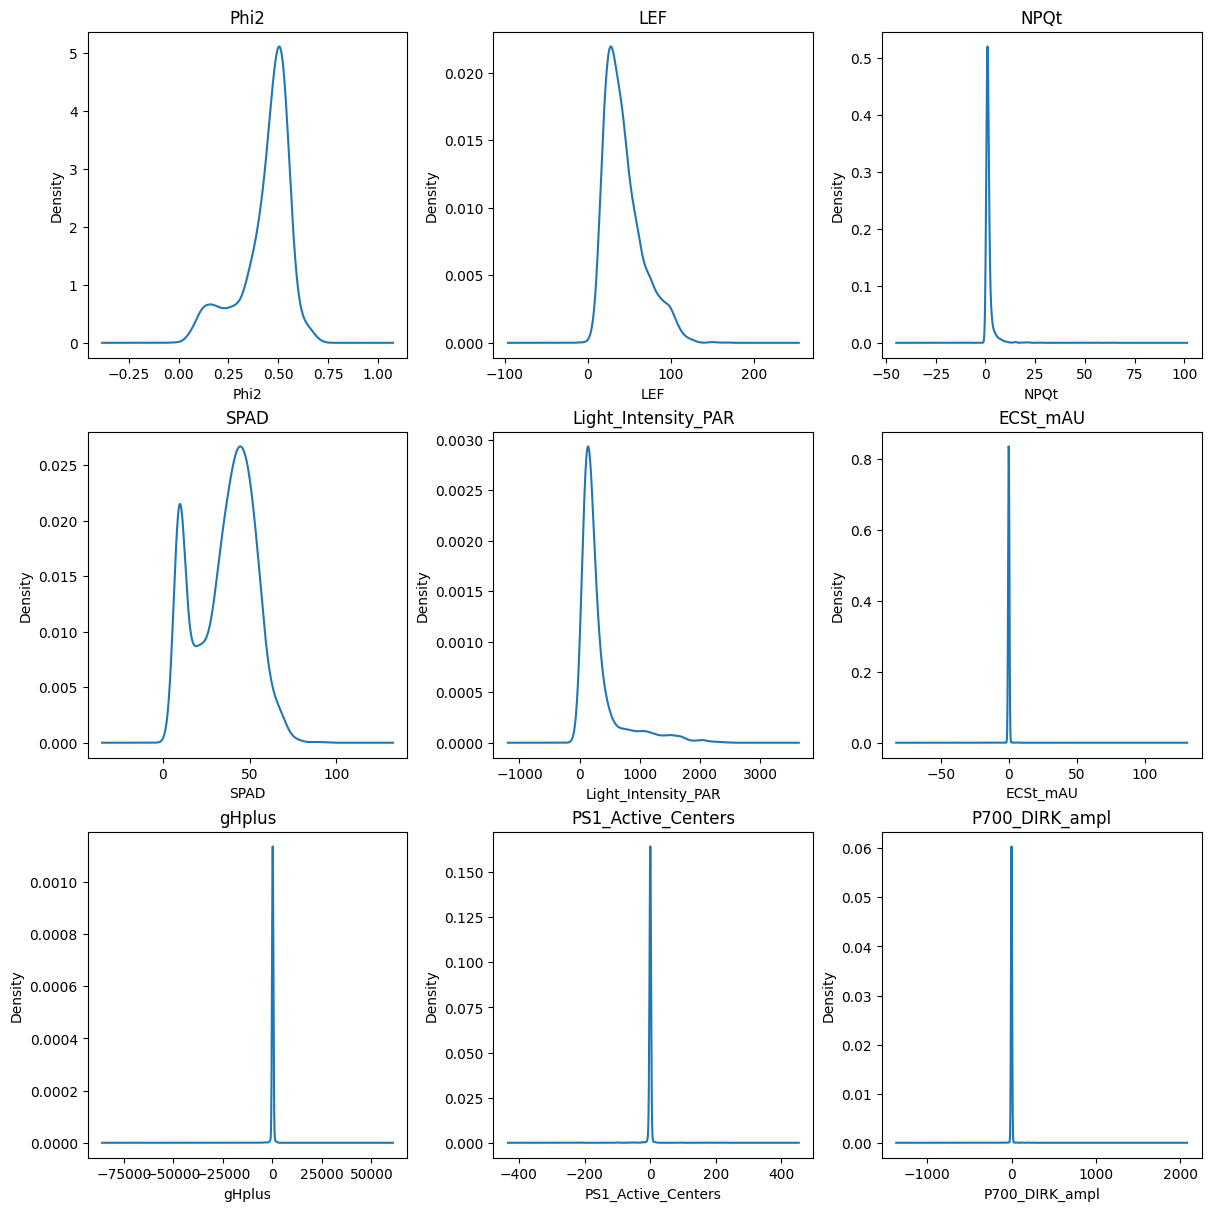

In [4]:
kde_cols = [
    "Phi2",
    "LEF",
    "NPQt",
    "SPAD",
    "Light_Intensity_PAR",
    "ECSt_mAU",
    "gHplus",
    "PS1_Active_Centers",
    "P700_DIRK_ampl",
]

fig, axs = plt.subplots(3, 3, figsize=(12, 12), layout="constrained")
for ax, col in zip(axs.flatten(), kde_cols):
    df[col].dropna().plot(kind="kde", ax=ax)
    ax.set(title=col, xlabel=col)

[Text(0.5, 1.0, 'Phi2 by heterotic pool'),
 Text(0.5, 0, 'Heterotic pool'),
 Text(0, 0.5, 'Phi2')]

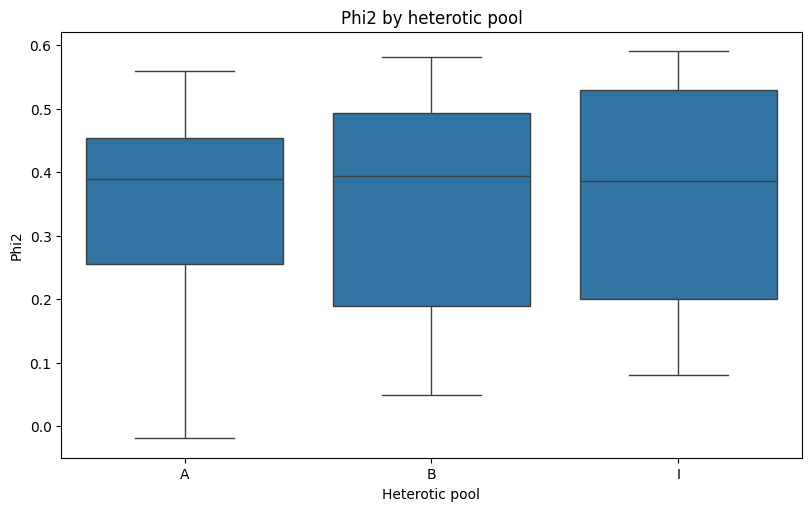

In [5]:
df_pools = df[df["heterotic_pool"].isin(["A", "B", "I"])]

fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
sns.boxplot(data=df_pools, x="heterotic_pool", y="Phi2", ax=ax)
ax.set(title="Phi2 by heterotic pool", xlabel="Heterotic pool", ylabel="Phi2")

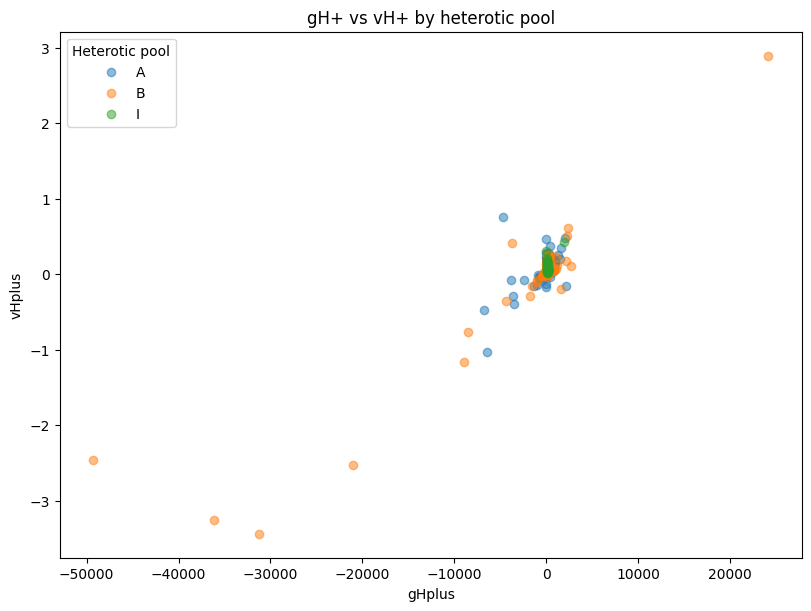

In [6]:
fig, ax = plt.subplots(figsize=(8, 6), layout="constrained")
for pool, grp in df_pools.groupby("heterotic_pool"):
    ax.scatter(grp["gHplus"], grp["vHplus"], label=pool, alpha=0.5)
ax.set(title="gH+ vs vH+ by heterotic pool", xlabel="gHplus", ylabel="vHplus")
ax.legend(title="Heterotic pool")

In [7]:
df.describe()

,latitude,longitude,Phi2,PhiNPQ,PhiNO,NPQt,LEF,qL,FmPrime,FoPrime,...,PS1_Active_Centers,PS1_Open_Centers,PS1_Over_Reduced_Centers,PS1_Oxidized_Centers,P700_DIRK_ampl,kP700,tP700,v_initial_P700,leaf_angle,leaf_thickness
count,3221.000000,3221.000000,3221.000000,3221.000000,3221.000000,3221.000000,3221.000000,3221.000000,3221.000000,3221.000000,...,3221.000000,3196.000000,3196.000000,3196.000000,3207.000000,3207.000000,3.207000e+03,3207.000000,3221.000000,3221.000000
mean,50.139315,5.454950,0.438625,0.320390,0.240996,1.702515,43.380478,0.387736,3602.694225,1108.591121,...,0.083647,0.267592,0.260728,0.471693,1.082952,-67.463123,-2.321310e+04,0.027085,24.102783,0.133698
std,9.649260,1.049800,0.125064,0.150829,0.058158,2.648653,23.291316,0.181639,1140.238883,224.146870,...,10.066471,6.502221,6.080589,5.713814,32.730665,4017.054509,9.837377e+05,0.447617,15.670208,0.330567
min,0.000000,0.000000,-0.019000,-0.081000,-0.114000,-8.306000,-8.860000,-0.296000,100.610000,81.000000,...,-211.925000,-239.993000,-119.490000,-62.981000,-504.408470,-186302.255500,-4.944982e+07,-14.904180,0.659000,-0.030000
25%,51.995812,5.656536,0.394000,0.222000,0.214000,0.835000,26.120000,0.327000,2816.300000,1030.000000,...,-0.202000,-0.021000,-0.444500,-0.095250,0.000120,45.210300,1.650000e-03,0.009664,12.558000,0.080000
50%,51.995959,5.656605,0.475000,0.274000,0.245000,1.085000,37.870000,0.396000,3780.320000,1164.000000,...,0.665000,0.385000,0.053500,0.280000,0.000220,158.598200,4.600000e-03,0.043964,20.927000,0.090000
75%,51.996012,5.657611,0.521000,0.369000,0.272000,1.618000,55.330000,0.457000,4411.140000,1252.000000,...,1.216000,0.853000,1.054000,0.769000,0.000400,275.257900,7.800000e-03,0.090869,31.742000,0.100000
max,52.004506,5.690590,0.710000,0.949000,0.487000,64.786000,166.380000,8.112000,7326.910000,1698.000000,...,231.656000,46.898000,205.500000,248.679000,1218.398150,20815.961900,5.568162e+05,2.256615,98.267000,4.580000


## Correlation Heatmap

In [ ]:
corr_cols = [
    "Phi2", "PhiNPQ", "PhiNO", "NPQt", "LEF", "qL", "SPAD",
    "ECSt_mAU", "gHplus", "vHplus",
    "PS1_Active_Centers", "PS1_Open_Centers", "P700_DIRK_ampl",
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10), layout="constrained")
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
)
ax.set(title="Correlation heatmap — key phenotypes")

## Energy Partitioning

Phi2 + PhiNPQ + PhiNO should sum to ~1 (energy balance). The three fractions are shown by heterotic pool (A, B, I only).

In [ ]:
energy_cols = ["Phi2", "PhiNPQ", "PhiNO"]
df_energy = df.loc[df["heterotic_pool"].isin(["A", "B", "I"]), energy_cols + ["heterotic_pool"]].dropna()

fig, axs = plt.subplots(1, 3, figsize=(12, 5), layout="constrained", sharey=True)
for ax, col in zip(axs, energy_cols):
    sns.violinplot(data=df_energy, x="heterotic_pool", y=col, ax=ax, order=["A", "B", "I"])
    ax.set(title=col, xlabel="Heterotic pool", ylabel=col if ax == axs[0] else "")

fig.suptitle("Energy partitioning (Phi2 + PhiNPQ + PhiNO ≈ 1) by heterotic pool")

# Also show a stacked bar chart of the means
means = df_energy.groupby("heterotic_pool")[energy_cols].mean().loc[["A", "B", "I"]]

fig2, ax2 = plt.subplots(figsize=(6, 5), layout="constrained")
means.plot(kind="bar", stacked=True, ax=ax2, color=["#2ca02c", "#ff7f0e", "#1f77b4"])
ax2.set(
    title="Mean energy partitioning by heterotic pool",
    xlabel="Heterotic pool",
    ylabel="Fraction",
)
ax2.legend(title="Component")
ax2.axhline(1.0, color="black", linestyle="--", linewidth=0.8, label="Sum = 1")

## Heritability

Broad-sense heritability (H²) for key photosynthetic parameters, filtered to genotypes with more than 3 measurements.

In [ ]:
from src import drop_na_multiple, heritability

pheno_cols = ["Phi2", "LEF", "NPQt", "SPAD", "ECSt_mAU", "gHplus", "PS1_Active_Centers"]
data = df[pheno_cols]
gtype = df["genotype"]

# Drop rows with any NaN across phenotype data and genotype
data, gtype = drop_na_multiple(data, gtype)

# Keep only genotypes with more than 3 entries
counts = gtype.value_counts()
keep = counts[counts > 3].index
mask = gtype.isin(keep)
data = data[mask]
gtype = gtype[mask]

h2 = heritability(data=data, gtype=gtype)
h2.plot()
h2.as_frame()

In [ ]:
# Top 10 genotypes ranked by mean Phi2
top10 = (
    df.groupby("genotype")["Phi2"]
    .mean()
    .dropna()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
top10.plot(kind="bar", ax=ax, color="teal")
ax.set(
    title="Top 10 genotypes by mean Phi2",
    xlabel="Genotype",
    ylabel="Mean Phi2",
)